# Airborne Object Detection — Dataset Analysis
**Model**: YOLOv26s | **Classes**: aeroplane, bird, drone, helicopter | **Format**: YOLOv8 labels

In [1]:
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

ROOT = Path('aod_dataset')
IMAGE_ROOT = ROOT / 'images'
LABEL_ROOT = ROOT / 'labels'
SPLITS = ['train', 'valid', 'test']
CLASS_NAMES = {0: 'aeroplane', 1: 'bird', 2: 'drone', 3: 'helicopter'}
COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
SPLIT_COLORS = {'train': '#4C72B0', 'valid': '#55A868', 'test': '#C44E52'}

print('Setup done.')

Setup done.


In [2]:
def parse_all_labels():
    """Parse every label file once. Returns structured data for all visualizations."""
    data = {}
    for split in SPLITS:
        label_dir = LABEL_ROOT / split
        image_dir = IMAGE_ROOT / split
        records = []  # list of (stem, class_id, x_c, y_c, w, h)
        empty_stems = []
        for lp in label_dir.glob('*.txt'):
            content = lp.read_text().strip()
            if not content:
                empty_stems.append(lp.stem)
                continue
            for line in content.splitlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    cid = int(parts[0])
                    xc, yc, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    records.append((lp.stem, cid, xc, yc, w, h))
        # orphan images (no label file)
        img_stems = {p.stem for p in image_dir.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}}
        lbl_stems = {p.stem for p in label_dir.glob('*.txt')}
        orphans = img_stems - lbl_stems
        empty_stems.extend(orphans)
        data[split] = {'records': records, 'empty_stems': empty_stems}
    return data

DATA = parse_all_labels()
print(f'Parsed labels: {sum(len(d["records"]) for d in DATA.values())} annotations across {len(SPLITS)} splits.')

Parsed labels: 31595 annotations across 3 splits.


## 1. Annotations per Category per Split

Category           Train    Valid     Test    Total
--------------------------------------------------
aeroplane           5505     1625      767     7897
bird                5522     1557      821     7900
drone               5500     1602      796     7898
helicopter          5528     1585      787     7900
no object            415      125       56      596
--------------------------------------------------
TOTAL              22470     6494     3227    32191


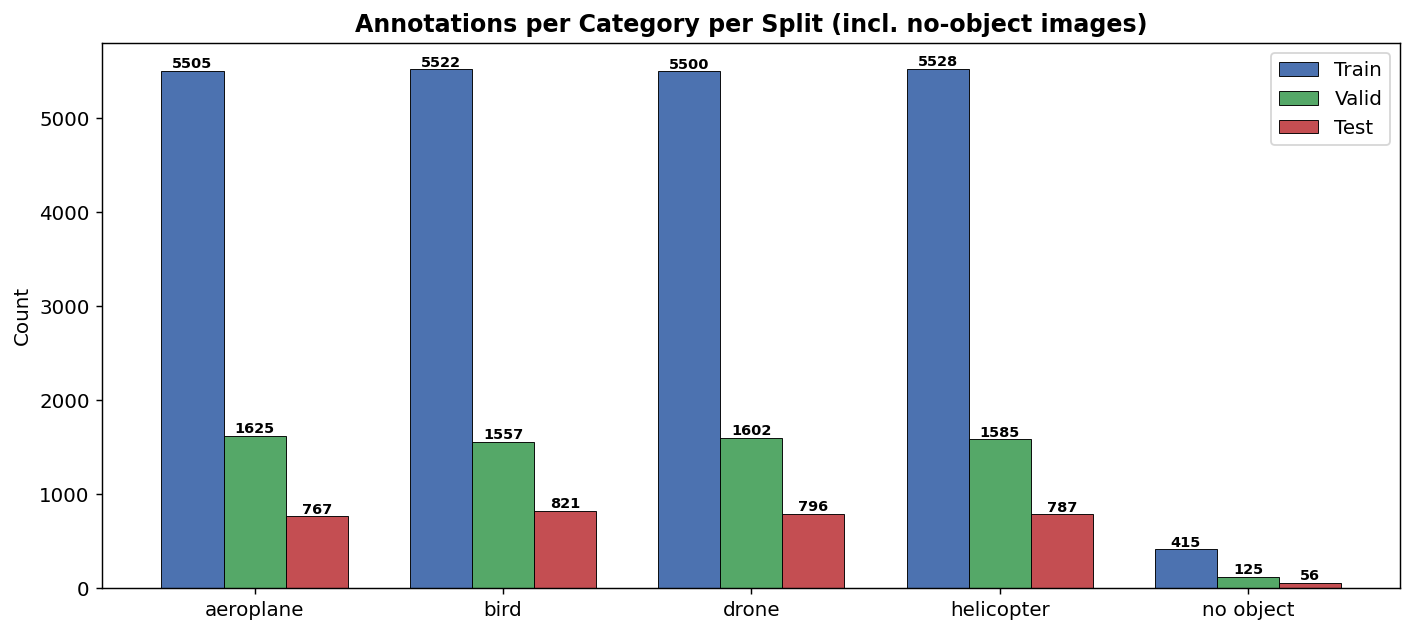

In [3]:
# Count annotations per class per split + empty label counts
annot_counts = {}
empty_counts = {}
for split in SPLITS:
    counts = defaultdict(int)
    for stem, cid, xc, yc, w, h in DATA[split]['records']:
        counts[cid] += 1
    annot_counts[split] = counts
    empty_counts[split] = len(DATA[split]['empty_stems'])

# Print table
print(f"{'Category':<15} {'Train':>8} {'Valid':>8} {'Test':>8} {'Total':>8}")
print('-' * 50)
for cid in sorted(CLASS_NAMES.keys()):
    t = annot_counts['train'].get(cid, 0)
    v = annot_counts['valid'].get(cid, 0)
    te = annot_counts['test'].get(cid, 0)
    print(f"{CLASS_NAMES[cid]:<15} {t:>8} {v:>8} {te:>8} {t+v+te:>8}")
et, ev, ete = empty_counts['train'], empty_counts['valid'], empty_counts['test']
print(f"{'no object':<15} {et:>8} {ev:>8} {ete:>8} {et+ev+ete:>8}")
print('-' * 50)
tt = sum(annot_counts['train'].values()) + et
tv = sum(annot_counts['valid'].values()) + ev
tte = sum(annot_counts['test'].values()) + ete
print(f"{'TOTAL':<15} {tt:>8} {tv:>8} {tte:>8} {tt+tv+tte:>8}")

# Plot — include 'no object' as a category
fig, ax = plt.subplots(figsize=(11, 5))
categories = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())] + ['no object']
x = np.arange(len(categories))
width = 0.25
for i, split in enumerate(SPLITS):
    vals = [annot_counts[split].get(cid, 0) for cid in sorted(CLASS_NAMES.keys())] + [empty_counts[split]]
    bars = ax.bar(x + i * width, vals, width, label=split.capitalize(), color=SPLIT_COLORS[split], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, str(val), ha='center', fontsize=8, fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Annotations per Category per Split (incl. no-object images)', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Images per Category per Split
How many **images** contain at least one object of each class (plus images with no objects).

Category           Train    Valid     Test    Total
--------------------------------------------------
aeroplane           3882     1119      551     5552
bird                2255      638      320     3213
drone               5197     1485      742     7424
helicopter          4032     1158      574     5764
no object            415      125       56      596
--------------------------------------------------


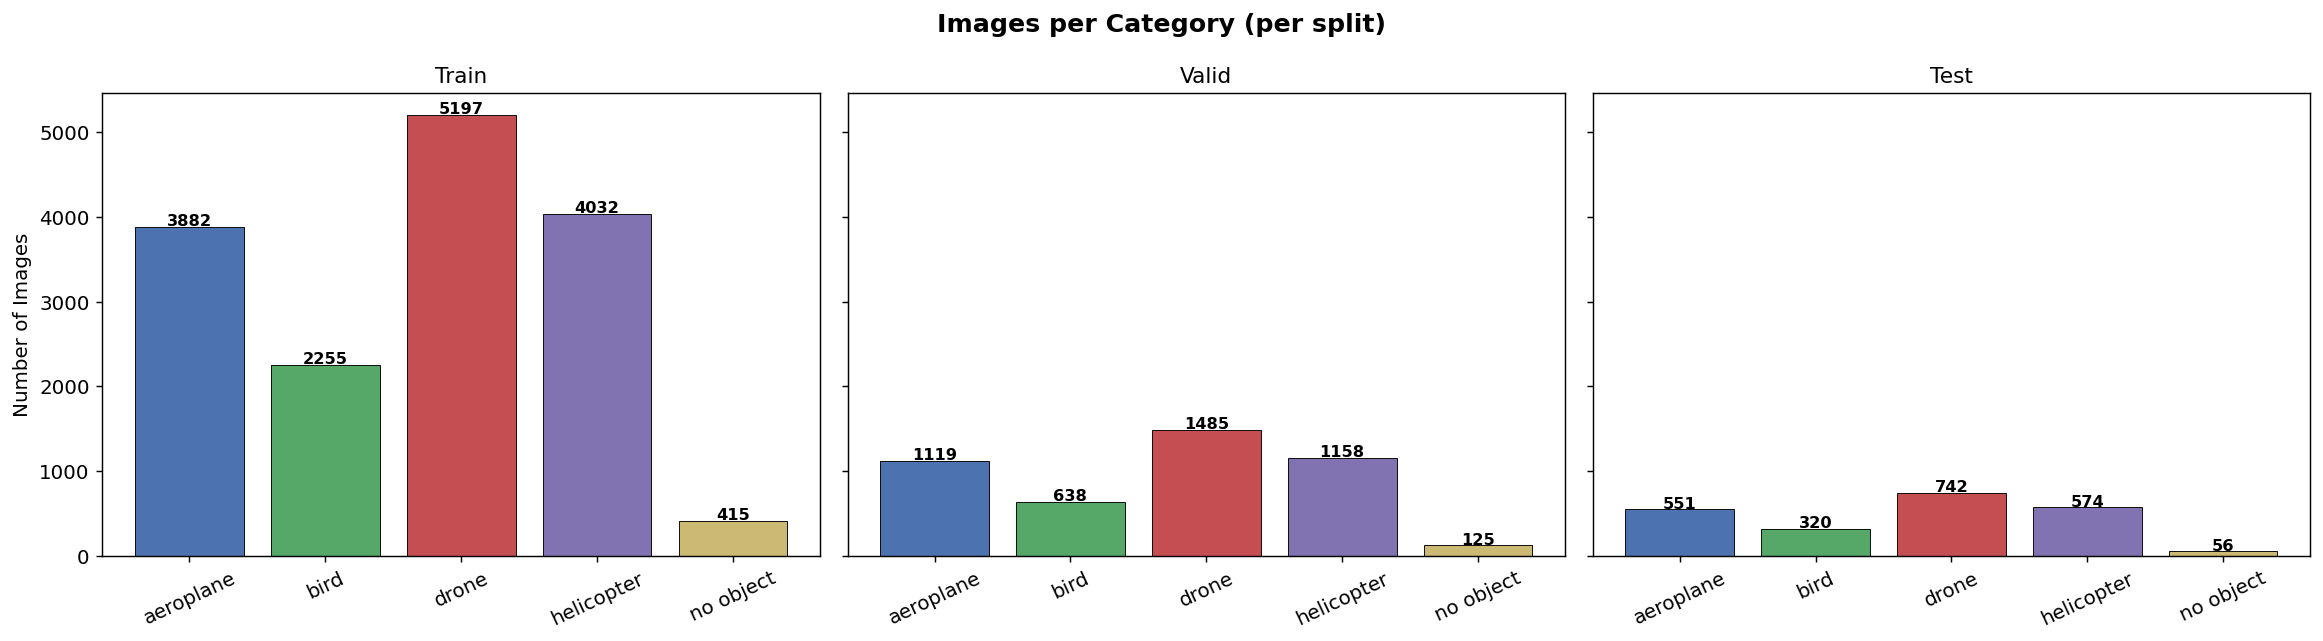

In [4]:
def images_per_category(split):
    cat_imgs = defaultdict(set)
    for stem, cid, xc, yc, w, h in DATA[split]['records']:
        cat_imgs[cid].add(stem)
    no_obj = len(DATA[split]['empty_stems'])
    return cat_imgs, no_obj

all_cats = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())] + ['no object']

# Print table
print(f"{'Category':<15} {'Train':>8} {'Valid':>8} {'Test':>8} {'Total':>8}")
print('-' * 50)
for cid in sorted(CLASS_NAMES.keys()):
    row = []
    for split in SPLITS:
        ci, _ = images_per_category(split)
        row.append(len(ci.get(cid, set())))
    print(f"{CLASS_NAMES[cid]:<15} {row[0]:>8} {row[1]:>8} {row[2]:>8} {sum(row):>8}")
row_no = []
for split in SPLITS:
    _, no = images_per_category(split)
    row_no.append(no)
print(f"{'no object':<15} {row_no[0]:>8} {row_no[1]:>8} {row_no[2]:>8} {sum(row_no):>8}")
print('-' * 50)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Images per Category (per split)', fontsize=14, fontweight='bold')
for idx, split in enumerate(SPLITS):
    ci, no = images_per_category(split)
    vals = [len(ci.get(cid, set())) for cid in sorted(CLASS_NAMES.keys())] + [no]
    bars = axes[idx].bar(all_cats, vals, color=COLORS, edgecolor='black', linewidth=0.5)
    axes[idx].set_title(f'{split.capitalize()}', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15, str(val), ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Number of Images')
plt.tight_layout()
plt.show()

## 3. Bounding Box Size Distribution
How large/small are the objects? Critical for choosing `imgsz` (640 vs 1024) with YOLOv26's STAL.

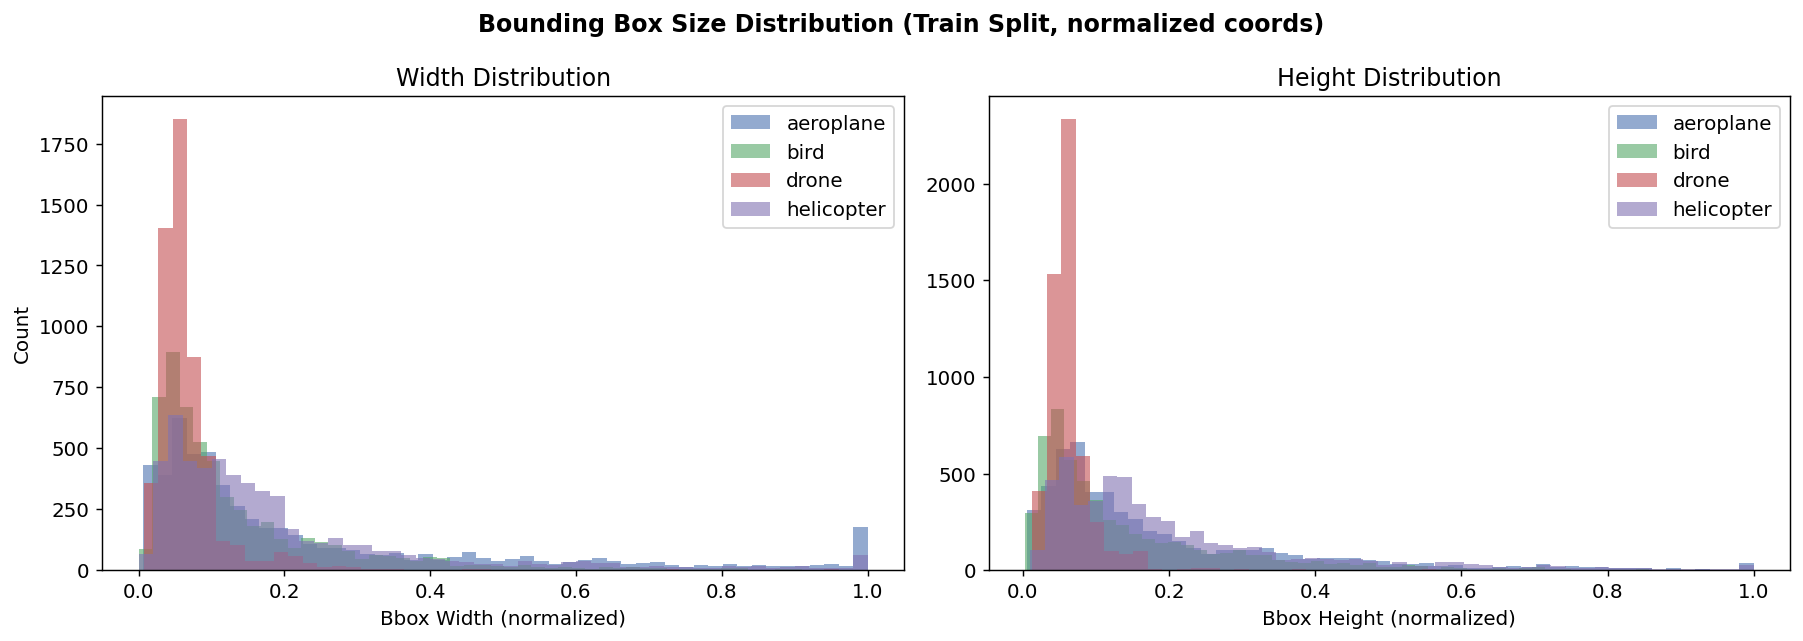

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bounding Box Size Distribution (Train Split, normalized coords)', fontweight='bold')

for cid in sorted(CLASS_NAMES.keys()):
    widths = [w for _, c, xc, yc, w, h in DATA['train']['records'] if c == cid]
    heights = [h for _, c, xc, yc, w, h in DATA['train']['records'] if c == cid]
    axes[0].hist(widths, bins=50, alpha=0.6, label=CLASS_NAMES[cid], color=COLORS[cid])
    axes[1].hist(heights, bins=50, alpha=0.6, label=CLASS_NAMES[cid], color=COLORS[cid])

axes[0].set_xlabel('Bbox Width (normalized)')
axes[0].set_ylabel('Count')
axes[0].set_title('Width Distribution')
axes[0].legend()
axes[1].set_xlabel('Bbox Height (normalized)')
axes[1].set_title('Height Distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Bounding Box Area Distribution
Shows how "small" the objects really are — important for deciding imgsz.

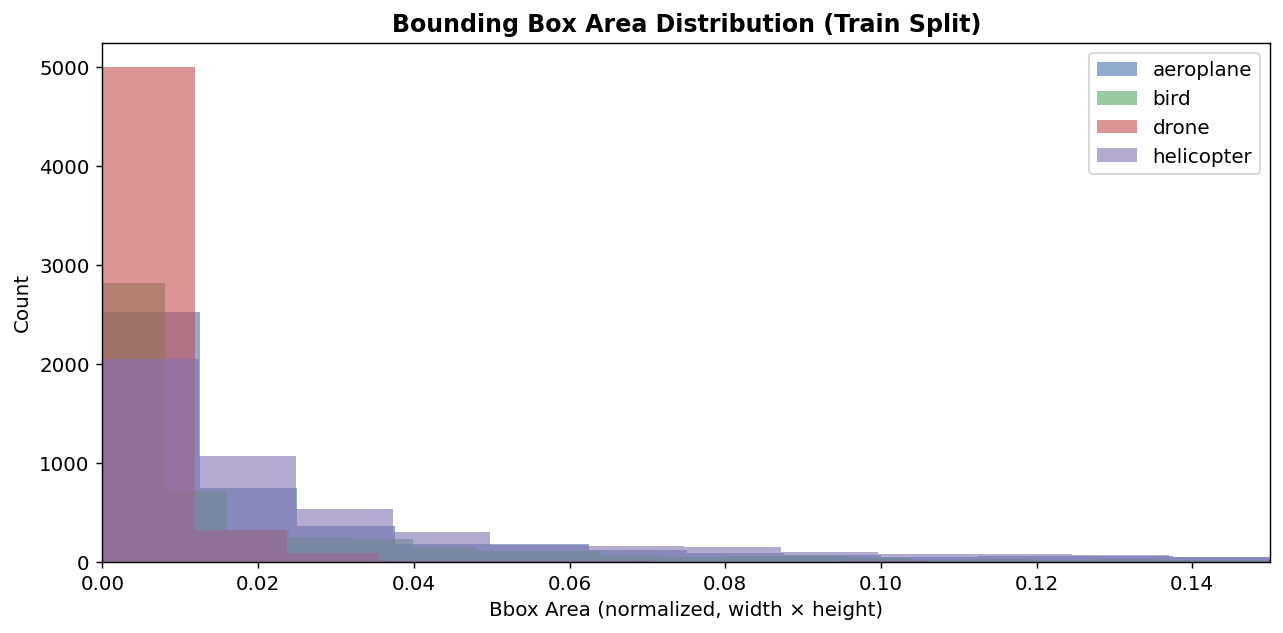

Median bbox area (normalized) per class:
  aeroplane   : 0.01565  (at 640px: ~6409 px²,  at 1024px: ~16408 px²)
  bird        : 0.00767  (at 640px: ~3141 px²,  at 1024px: ~8041 px²)
  drone       : 0.00317  (at 640px: ~1300 px²,  at 1024px: ~3328 px²)
  helicopter  : 0.02016  (at 640px: ~8259 px²,  at 1024px: ~21144 px²)


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for cid in sorted(CLASS_NAMES.keys()):
    areas = [w * h for _, c, xc, yc, w, h in DATA['train']['records'] if c == cid]
    ax.hist(areas, bins=80, alpha=0.6, label=CLASS_NAMES[cid], color=COLORS[cid])

ax.set_xlabel('Bbox Area (normalized, width × height)')
ax.set_ylabel('Count')
ax.set_title('Bounding Box Area Distribution (Train Split)', fontweight='bold')
ax.legend()
ax.set_xlim(0, 0.15)  # zoom into small objects
plt.tight_layout()
plt.show()

# Print median areas
print('Median bbox area (normalized) per class:')
for cid in sorted(CLASS_NAMES.keys()):
    areas = [w * h for _, c, xc, yc, w, h in DATA['train']['records'] if c == cid]
    print(f'  {CLASS_NAMES[cid]:<12}: {np.median(areas):.5f}  (at 640px: ~{np.median(areas) * 640 * 640:.0f} px²,  at 1024px: ~{np.median(areas) * 1024 * 1024:.0f} px²)')

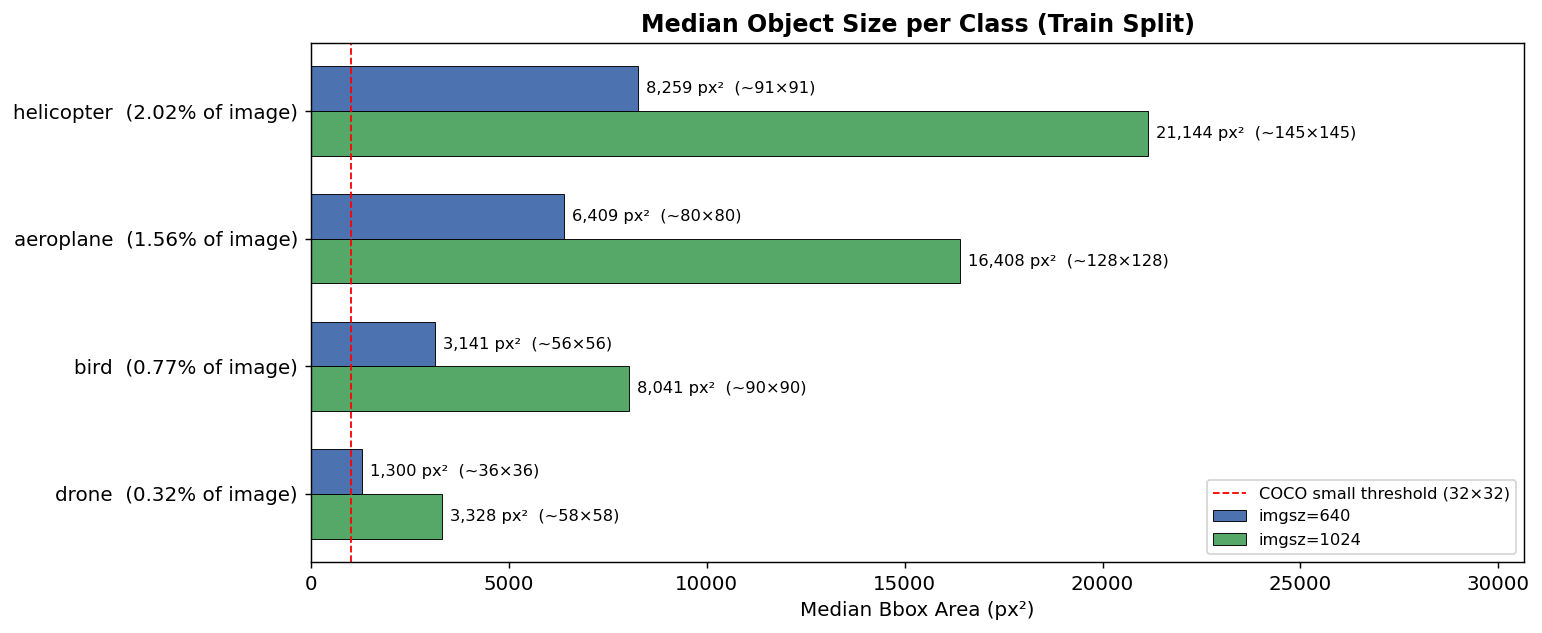

In [8]:
# Median bbox area — ordered smallest to largest, % on y-axis labels
median_data = {}
for cid in sorted(CLASS_NAMES.keys()):
    areas = [w * h for _, c, xc, yc, w, h in DATA['train']['records'] if c == cid]
    median_data[CLASS_NAMES[cid]] = np.median(areas)

# Order: drone, bird, aeroplane, helicopter
order = ['drone', 'bird', 'aeroplane', 'helicopter']
norm_areas = [median_data[c] for c in order]
px_640 = [a * 640 * 640 for a in norm_areas]
px_1024 = [a * 1024 * 1024 for a in norm_areas]
side_640 = [np.sqrt(p) for p in px_640]
side_1024 = [np.sqrt(p) for p in px_1024]
pct = [a * 100 for a in norm_areas]

# Y-axis labels include % of image
y_labels = [f'{c}  ({p:.2f}% of image)' for c, p in zip(order, pct)]

fig, ax = plt.subplots(figsize=(12, 5))
y = np.arange(len(order))
h = 0.35
bars1 = ax.barh(y + h/2, px_640, h, label='imgsz=640', color='#4C72B0', edgecolor='black', linewidth=0.5)
bars2 = ax.barh(y - h/2, px_1024, h, label='imgsz=1024', color='#55A868', edgecolor='black', linewidth=0.5)

for bar, val, s in zip(bars1, px_640, side_640):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} px²  (~{s:.0f}×{s:.0f})', va='center', fontsize=9)
for bar, val, s in zip(bars2, px_1024, side_1024):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} px²  (~{s:.0f}×{s:.0f})', va='center', fontsize=9)

ax.axvline(x=1024, color='red', linestyle='--', linewidth=1, label='COCO small threshold (32×32)')
ax.set_yticks(y)
ax.set_yticklabels(y_labels, fontsize=11)
ax.set_xlabel('Median Bbox Area (px²)')
ax.set_title('Median Object Size per Class (Train Split)', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, max(px_1024) * 1.45)
plt.tight_layout()
plt.show()


## 5. Bounding Box Center Heatmap
Where in the image do objects tend to appear?

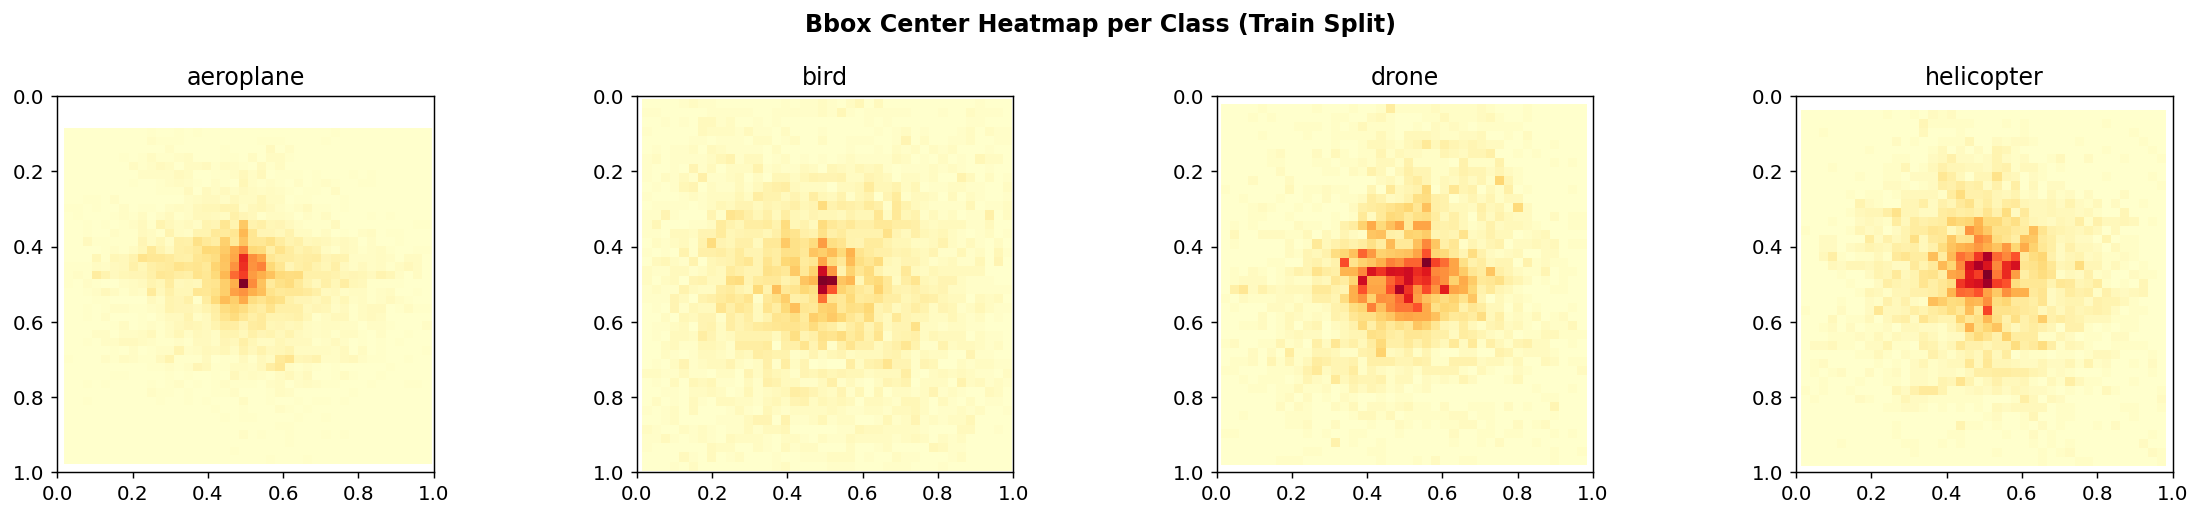

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Bbox Center Heatmap per Class (Train Split)', fontweight='bold')

for idx, cid in enumerate(sorted(CLASS_NAMES.keys())):
    xs = [xc for _, c, xc, yc, w, h in DATA['train']['records'] if c == cid]
    ys = [yc for _, c, xc, yc, w, h in DATA['train']['records'] if c == cid]
    axes[idx].hist2d(xs, ys, bins=40, cmap='YlOrRd')
    axes[idx].set_title(CLASS_NAMES[cid])
    axes[idx].set_xlim(0, 1)
    axes[idx].set_ylim(1, 0)  # flip y so top-left is origin like images
    axes[idx].set_aspect('equal')

plt.tight_layout()
plt.show()

## 6. Aspect Ratio Distribution per Class

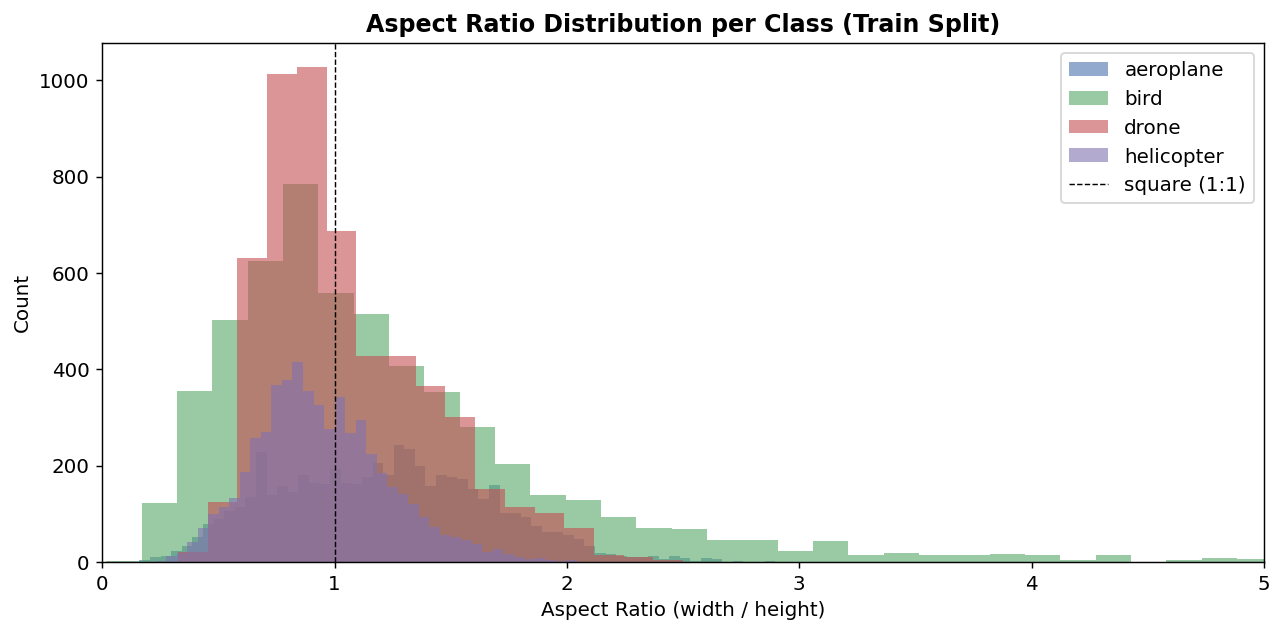

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for cid in sorted(CLASS_NAMES.keys()):
    ratios = [w / h if h > 0 else 0 for _, c, xc, yc, w, h in DATA['train']['records'] if c == cid]
    ax.hist(ratios, bins=60, alpha=0.6, label=CLASS_NAMES[cid], color=COLORS[cid])

ax.set_xlabel('Aspect Ratio (width / height)')
ax.set_ylabel('Count')
ax.set_title('Aspect Ratio Distribution per Class (Train Split)', fontweight='bold')
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=0.8, label='square (1:1)')
ax.legend()
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

## 7. Objects per Image Histogram

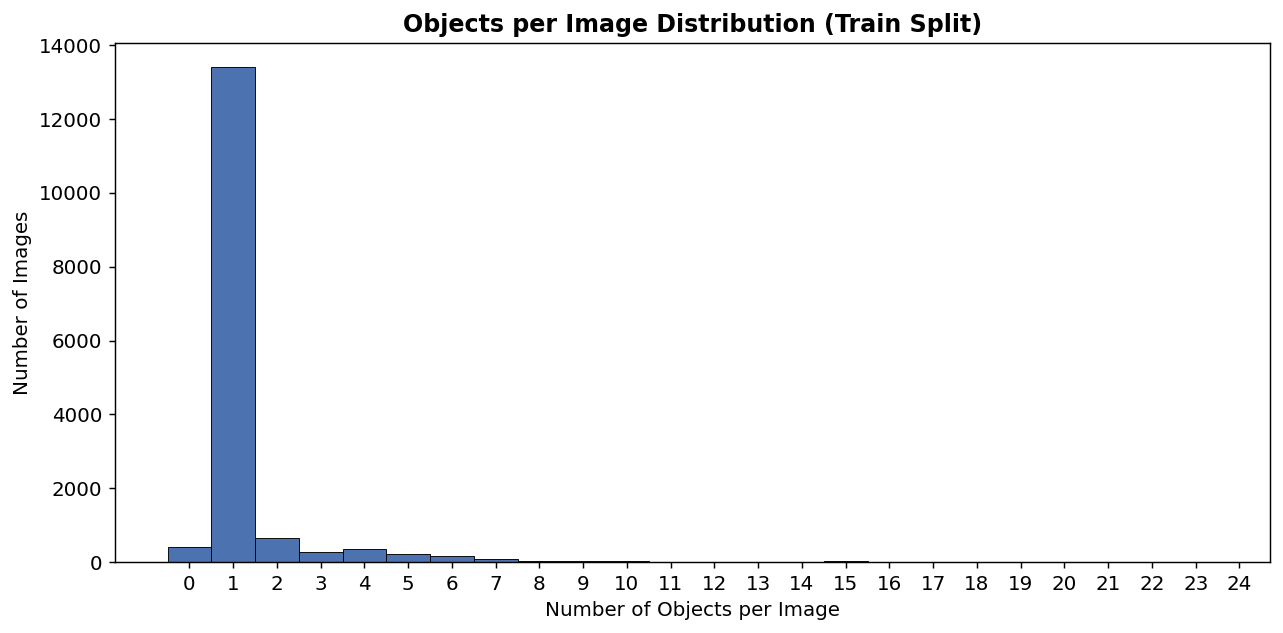

Min: 0, Max: 36, Median: 1, Mean: 1.40


In [9]:
# Count objects per image for train split
objs_per_img = defaultdict(int)
for stem, cid, xc, yc, w, h in DATA['train']['records']:
    objs_per_img[stem] += 1
# Add empty images as 0
for stem in DATA['train']['empty_stems']:
    objs_per_img[stem] = 0

counts_list = list(objs_per_img.values())

fig, ax = plt.subplots(figsize=(10, 5))
max_objs = max(counts_list)
bins = range(0, min(max_objs + 2, 25))
ax.hist(counts_list, bins=bins, color='#4C72B0', edgecolor='black', linewidth=0.5, align='left')
ax.set_xlabel('Number of Objects per Image')
ax.set_ylabel('Number of Images')
ax.set_title('Objects per Image Distribution (Train Split)', fontweight='bold')
ax.set_xticks(range(0, min(max_objs + 1, 25)))
plt.tight_layout()
plt.show()

print(f'Min: {min(counts_list)}, Max: {max(counts_list)}, Median: {np.median(counts_list):.0f}, Mean: {np.mean(counts_list):.2f}')

## 8. Multi-Class Co-occurrence Matrix
Which classes appear together in the same image?

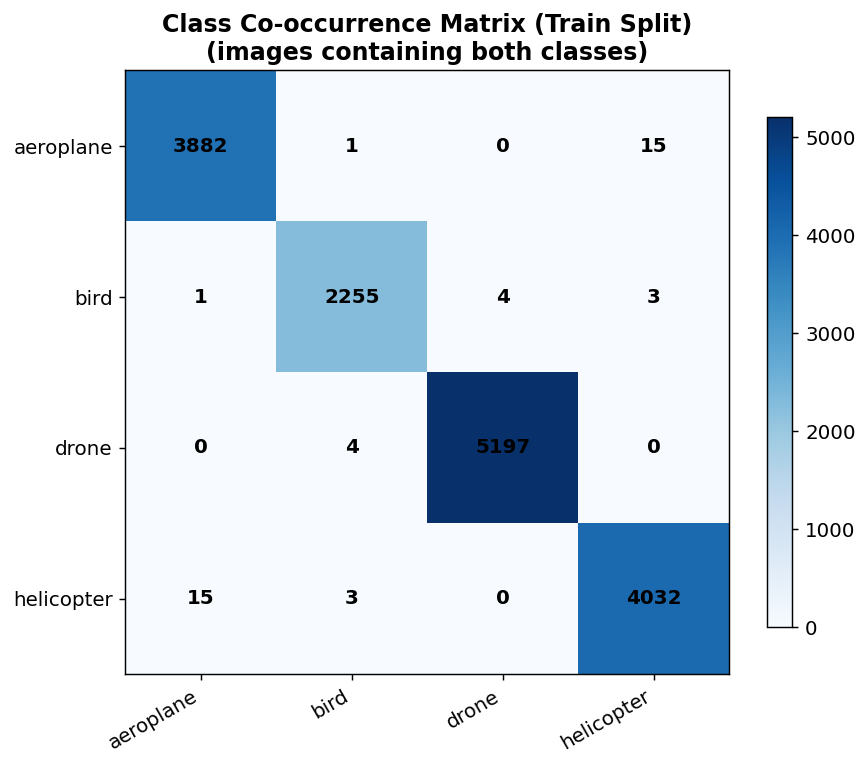

In [10]:
# Build co-occurrence for train split
img_classes = defaultdict(set)
for stem, cid, xc, yc, w, h in DATA['train']['records']:
    img_classes[stem].add(cid)

n_classes = len(CLASS_NAMES)
cooccur = np.zeros((n_classes, n_classes), dtype=int)
for stem, classes in img_classes.items():
    for c1 in classes:
        for c2 in classes:
            cooccur[c1][c2] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cooccur, cmap='Blues')
labels = [CLASS_NAMES[i] for i in range(n_classes)]
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_yticklabels(labels)
ax.set_title('Class Co-occurrence Matrix (Train Split)\n(images containing both classes)', fontweight='bold')

for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, str(cooccur[i][j]), ha='center', va='center', fontsize=11, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 9. Train / Valid / Test Split Proportions

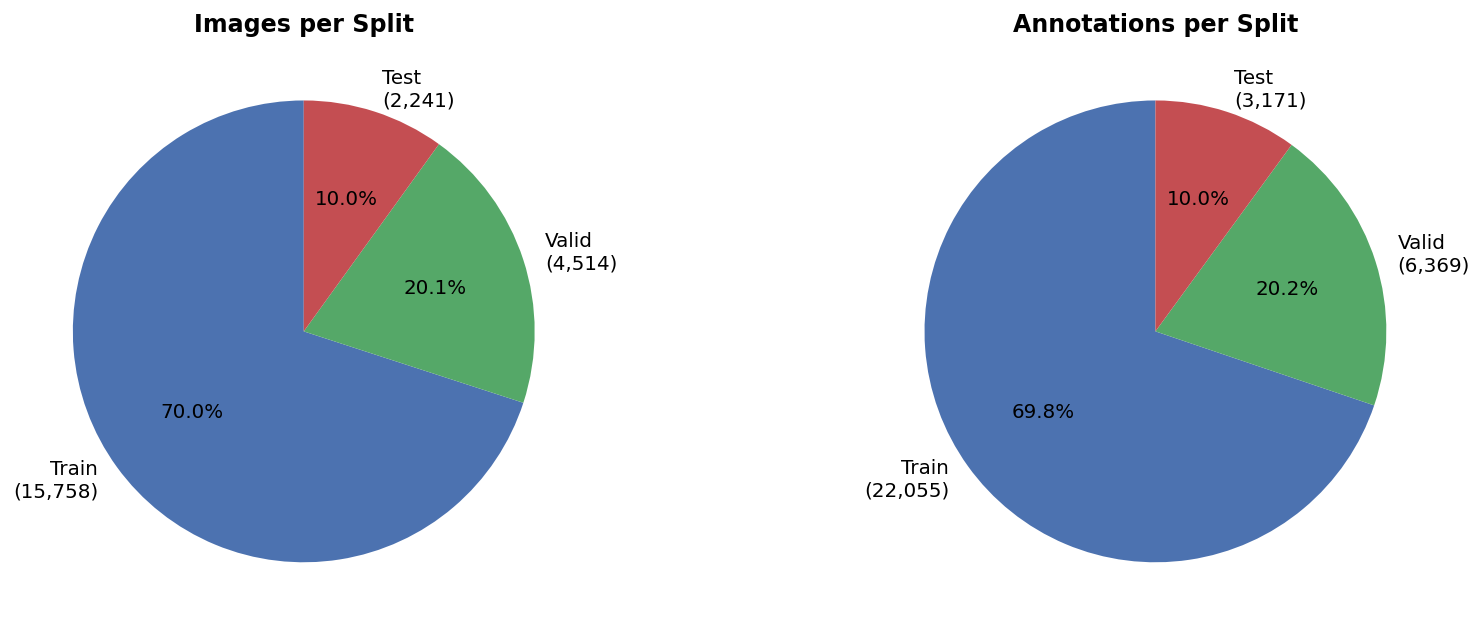

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: images per split
img_counts = []
for split in SPLITS:
    img_dir = IMAGE_ROOT / split
    img_counts.append(len([p for p in img_dir.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]))

axes[0].pie(img_counts, labels=[f'{s.capitalize()}\n({c:,})' for s, c in zip(SPLITS, img_counts)],
            colors=[SPLIT_COLORS[s] for s in SPLITS], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Images per Split', fontweight='bold')

# Pie chart: annotations per split
ann_counts = [sum(annot_counts[s].values()) for s in SPLITS]
axes[1].pie(ann_counts, labels=[f'{s.capitalize()}\n({c:,})' for s, c in zip(SPLITS, ann_counts)],
            colors=[SPLIT_COLORS[s] for s in SPLITS], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Annotations per Split', fontweight='bold')

plt.tight_layout()
plt.show()